In [ ]:
import torch

print(f"torch version: {torch.__version__}")
print(f"torch cuda version: {torch.version.cuda}")
device = torch.device(torch.cuda.current_device() if torch.cuda.is_available() else "cpu")
print(f"torch device: {device}")
print(f"device name: {torch.cuda.get_device_name(device) if torch.cuda.is_available() else 'cpu'}")

torch version: 2.6.0+cu126
torch cuda version: 12.6
torch device: cuda:0
device name: NVIDIA GeForce RTX 4090 Laptop GPU


In [ ]:
import os

from common import SAVE_MODEL_PATH
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj"],
)


sa_merge_model = AutoModelForCausalLM.from_pretrained(
    os.path.join(SAVE_MODEL_PATH, "mistral-7b-lora-SA"),
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

sa_tokenizer = AutoTokenizer.from_pretrained(os.path.join(SAVE_MODEL_PATH, "mistral-7b-lora-SA"))
sa_tokenizer.pad_token = sa_tokenizer.eos_token

MISC_DATA_PATH: ..\..\MISC
JOB_DATA_PATH: ..\..\MISC\job_data_files


2025-04-27 23:21:03 - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
import re

import tqdm
from mistral_data import MissionType, MistralData

FuncFindAnswer = lambda text: (
    re.search(r"Answer: (.*)", text).group(1).strip()
    if re.search(r"Answer: (.*)", text)
    else "None"
)


def predict(Model, Tokenizer, MistralData: MistralData) -> list:
    y_pred = []
    test_data = MistralData.test_dataset["train"]
    # logger.info("Predicting...")
    for i in tqdm.tqdm(range(len(test_data))):
        input_text = test_data["input"][i]
        instruction_text = test_data["instruction"][i]
        format_input = f"<s>[INST] {instruction_text} {input_text} [/INST]"
        input_ids = Tokenizer(format_input, return_tensors="pt").input_ids.to(device)
        attention_mask = Tokenizer(format_input, return_tensors="pt").attention_mask.to(
            device
        )
        Model.gradient_checkpointing_enable()
        Model.generation_config.pad_token_id = Tokenizer.pad_token_id
        output = Model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_return_sequences=1,
            max_length=Model.config.max_position_embeddings,
        )
        Model.gradient_checkpointing_enable()
        # print(sequences[0]["generated_text"])
        output_text = Tokenizer.decode(output[0], skip_special_tokens=True)
        # print(f"Output: {output_text}")
        a = FuncFindAnswer(output_text)
        # print(f"Answer: {a}")
        y_pred.append(a)
    return y_pred


y_pred = predict(sa_merge_model, sa_tokenizer, MistralData(MissionType.SA))
y_test = MistralData(MissionType.SA).df_test["y_true"].tolist()

print(f"y_test: {y_test}")
print(f"y_pred: {y_pred}")

2025-04-27 23:24:32 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 2267/2267 [00:00<00:00, 56138.01it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-27 23:24:33 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 567/567 [00:00<00:00, 50035.14it/s]


Generating train split: 0 examples [00:00, ? examples/s]

100%|██████████| 567/567 [13:43<00:00,  1.45s/it]
2025-04-27 23:38:17 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 2267/2267 [00:00<00:00, 45237.58it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-27 23:38:17 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 567/567 [00:00<00:00, 49270.12it/s]


Generating train split: 0 examples [00:00, ? examples/s]

y_test: ['1500-1800-MYR-MONTHLY', '60-60-HKD-HOURLY', '0-0-None-None', '0-0-None-None', '0-0-None-None', '21-21-NZD-HOURLY', '0-0-None-None', '0-0-None-None', '32-32-AUD-HOURLY', '2000-3000-MYR-MONTHLY', '3000-4000-MYR-MONTHLY', '0-0-None-None', '0-0-None-None', '80-90-HKD-HOURLY', '142642-156491-AUD-ANNUAL', '0-0-None-None', '29-29-AUD-HOURLY', '1500-2500-MYR-MONTHLY', '66028-68086-AUD-ANNUAL', '0-0-None-None', '3000-4000-SGD-MONTHLY', '0-0-None-None', '0-0-None-None', '73-85-HKD-HOURLY', '5000-8000-MYR-MONTHLY', '30-30-NZD-HOURLY', '0-0-None-None', '500-1250-SGD-WEEKLY', '1500-1500-MYR-MONTHLY', '750-1125-SGD-WEEKLY', '0-0-None-None', '0-0-None-None', '0-0-None-None', '1500-1500-MYR-MONTHLY', '2000-2500-SGD-MONTHLY', '58008-58008-AUD-ANNUAL', '23-29-NZD-HOURLY', '3000-6000-MYR-MONTHLY', '31-31-NZD-HOURLY', '100-100-HKD-HOURLY', '500-667-PHP-DAILY', '107-150-SGD-DAILY', '1500-1500-MYR-MONTHLY', '20-25-AUD-HOURLY', '0-0-None-None', '0-0-None-None', '2700-3000-SGD-MONTHLY', '0-0-None-No

In [ ]:
import pandas as pd

df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred})
# df = pd.read_csv("./SA_Mistral_7B_Lora.csv")
# df.to_csv("SA_Mistral_7B_Lora.csv", index=False)
df.head()
y_true = df["y_true"].tolist()
y_pred = df["y_pred"].tolist()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: \t {accuracy:.8f}")
# Calculate precision

precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
print(f"Precision: \t {precision:.8f}")

# Calculate recall
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Recall: \t {recall:.8f}")

# Calculate F1 score
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
print(f"F1 Score: \t {f1:.8f}")

# # Generate classification report
# report = classification_report(y_test, y_pred, zero_division=0)
# print(f"Classification Report: \n{report}")

Accuracy: 	 0.91887125
Precision: 	 0.91950268
Recall: 	 0.91887125
F1 Score: 	 0.91581549


In [ ]:
import numpy as np

print(f"df: {df.shape}")

list_yt = np.zeros((df.shape[0], 4), dtype=object)
print(f"list_yt: {list_yt.shape}")
list_yp = np.zeros((df.shape[0], 4), dtype=object)
print(f"list_yp: {list_yp.shape}")
list_yp.fill("None")


for i, row in df.iterrows():
    list_yt[i] = row["y_true"].split("-")
    t = row["y_pred"].split("-")
    # print(f"t: {t}")
    if t[-1] == '':
        t[-1] = "None"
    list_yp[i] = t

list_yt_time = list_yt[:, 3].astype(str)
list_yt_currency = list_yt[:, 2].astype(str)
list_yt_amount = list_yt[:, [0, 1]].astype(float)
list_yp_time = list_yp[:, 3].astype(str)
list_yp_currency = list_yp[:, 2].astype(str)
list_yp_amount = list_yp[:, [0, 1]].astype(float)

def report(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, zero_division=0)
    print(f"Accuracy: \t {accuracy:.8f}")
    print(f"Precision: \t {precision:.8f}")
    print(f"Recall: \t {recall:.8f}")
    print(f"F1 Score: \t {f1:.8f}")
    print(f"Classification Report: \n{report}")

df: (567, 2)
list_yt: (567, 4)
list_yp: (567, 4)


Accuracy: 	 0.98236332
Precision: 	 0.98201567
Recall: 	 0.98236332
F1 Score: 	 0.98204730
Classification Report: 
              precision    recall  f1-score   support

         AUD       1.00      1.00      1.00        72
         HKD       1.00      1.00      1.00        54
         IDR       1.00      1.00      1.00         1
         MYR       1.00      0.98      0.99        58
         NZD       0.90      0.82      0.86        34
        None       0.98      0.99      0.98       238
         PHP       1.00      1.00      1.00        32
         SGD       0.98      1.00      0.99        53
         THB       1.00      1.00      1.00        25

    accuracy                           0.98       567
   macro avg       0.98      0.98      0.98       567
weighted avg       0.98      0.98      0.98       567

cm: [[235   0   0   0   0   0   0   0   3]
 [  0  54   0   0   0   0   0   0   0]
 [  0   0  32   0   0   0   0   0   0]
 [  0   0   0  53   0   0   0   0   0]
 [  0   0   0   1  5

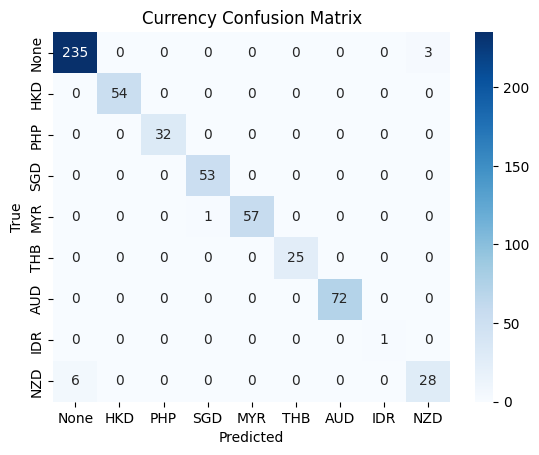

In [ ]:
report(list_yt_currency, list_yp_currency)

# plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = list(set(list_yt_currency))
cm = confusion_matrix(list_yt_currency, list_yp_currency, labels=labels)
print(f"cm: {cm}")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Currency Confusion Matrix")
plt.show()

Accuracy: 	 0.98412698
Precision: 	 0.98413373
Recall: 	 0.98412698
F1 Score: 	 0.98408405
Classification Report: 
              precision    recall  f1-score   support

      ANNUAL       1.00      1.00      1.00        26
       DAILY       1.00      1.00      1.00        14
      HOURLY       0.98      0.95      0.96       130
     MONTHLY       1.00      1.00      1.00       138
        None       0.98      0.99      0.98       238
      WEEKLY       1.00      1.00      1.00        21

    accuracy                           0.98       567
   macro avg       0.99      0.99      0.99       567
weighted avg       0.98      0.98      0.98       567

cm: [[235   3   0   0   0   0]
 [  6 124   0   0   0   0]
 [  0   0  26   0   0   0]
 [  0   0   0  21   0   0]
 [  0   0   0   0  14   0]
 [  0   0   0   0   0 138]]


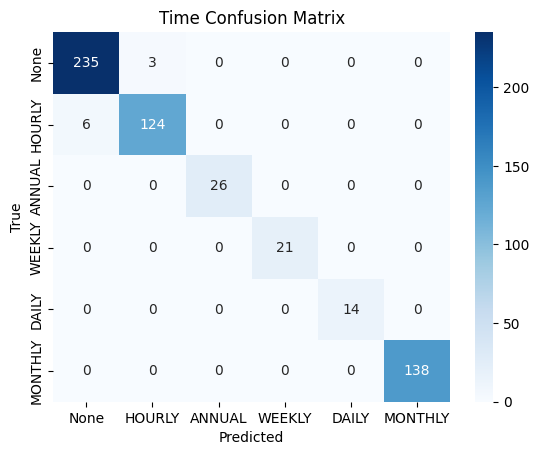

In [ ]:
report(list_yt_time, list_yp_time)

# plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = list(set(list_yt_time))
cm = confusion_matrix(list_yt_time, list_yp_time, labels=labels)
print(f"cm: {cm}")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Time Confusion Matrix")
plt.show()

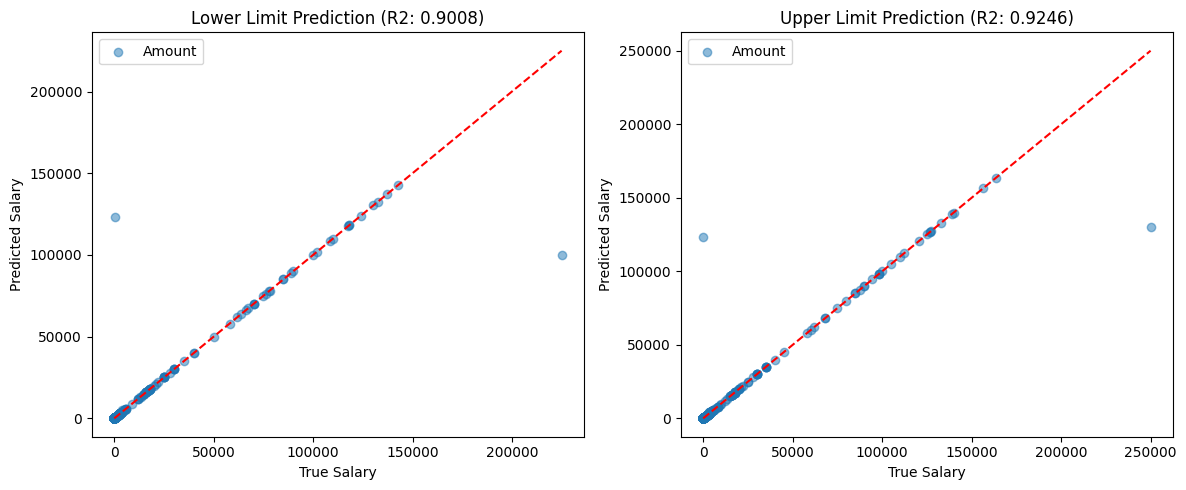

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

lower_limit = [list_yt_amount[:, 0].min(), list_yt_amount[:, 0].max()]
ax[0].scatter(list_yt_amount[:, 0], list_yp_amount[:, 0], alpha=0.5, label="Amount")
ax[0].plot(lower_limit, lower_limit, color="red", linestyle="--")
ax[0].set_title(f"Lower Limit Prediction (R2: {r2_score(list_yt_amount[:, 0], list_yp_amount[:, 0]):.4f})")
ax[0].set_xlabel("True Salary")
ax[0].set_ylabel("Predicted Salary")
ax[0].legend()

upper_limit = [list_yt_amount[:, 1].min(), list_yt_amount[:, 1].max()]
ax[1].scatter(list_yt_amount[:, 1], list_yp_amount[:, 1], alpha=0.5, label="Amount")
ax[1].plot(upper_limit, upper_limit, color="red", linestyle="--")
ax[1].set_title(f"Upper Limit Prediction (R2: {r2_score(list_yt_amount[:, 1], list_yp_amount[:, 1]):.4f})")
ax[1].set_xlabel("True Salary")
ax[1].set_ylabel("Predicted Salary")
ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
report(list_yt_amount[:, 0], list_yp_amount[:, 0])

Accuracy: 	 0.93827160
Precision: 	 0.93930145
Recall: 	 0.93827160
F1 Score: 	 0.93333755
Classification Report: 
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       238
        10.0       1.00      1.00      1.00         2
        12.0       1.00      1.00      1.00         1
        13.0       0.00      0.00      0.00         1
        14.0       0.00      0.00      0.00         0
        20.0       0.00      0.00      0.00         2
        21.0       1.00      1.00      1.00         1
        22.0       0.00      0.00      0.00         0
        23.0       1.00      0.67      0.80         3
        24.0       1.00      0.60      0.75         5
        25.0       0.50      0.67      0.57         3
        26.0       1.00      1.00      1.00         6
        27.0       1.00      1.00      1.00         4
        28.0       0.00      0.00      0.00         1
        29.0       0.80      1.00      0.89         4
        30.0       0

In [ ]:
report(list_yt_amount[:, 1], list_yp_amount[:, 1])

Accuracy: 	 0.94179894
Precision: 	 0.94296242
Recall: 	 0.94179894
F1 Score: 	 0.93812131
Classification Report: 
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       238
        10.0       0.50      1.00      0.67         1
        12.0       1.00      1.00      1.00         1
        13.0       0.00      0.00      0.00         1
        14.0       0.00      0.00      0.00         0
        21.0       1.00      1.00      1.00         1
        24.0       0.00      0.00      0.00         2
        25.0       1.00      0.50      0.67         2
        26.0       0.86      1.00      0.92         6
        27.0       1.00      1.00      1.00         2
        28.0       1.00      1.00      1.00         2
        29.0       1.00      0.75      0.86         4
        30.0       0.64      0.70      0.67        10
        31.0       1.00      0.80      0.89         5
        32.0       0.80      1.00      0.89         4
        33.0       0